---


# Agno — Install & Setup (Student Copy)

A clear, step-by-step setup with OS-specific commands, diagrams, and verification cells.



## Why use a virtual environment?

- Keep dependencies isolated per project.  
- Avoid version conflicts across different courses/projects.  
- Make onboarding/teaching predictable.

```mermaid
flowchart LR
  A[Python 3.x] --> B[Create venv]
  B --> C[Activate venv]
  C --> D[pip install -U agno]
  D --> E[Verify import]
```

<br>

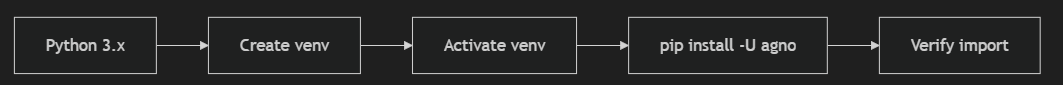

---


## Step 1 — Create & Activate a Virtual Environment

### macOS / Linux
```bash
python3 -m venv ~/.venvs/agno
source ~/.venvs/agno/bin/activate
```

### Windows (PowerShell)
```powershell
python3 -m venv agnoenv
.gnoenv\Scripts\Activate.ps1
```
> If PowerShell blocks activation, run PowerShell as Administrator and execute:  
> `Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope CurrentUser`


---


## Step 2 — Install the `agno` SDK

### macOS / Linux / Windows
```bash
pip install -U agno
```
> If you encounter errors, try updating pip first:
```bash
python -m pip install --upgrade pip
```


---


## Step 3 — (Optional) Upgrade `agno` later
```bash
pip install -U agno --no-cache-dir
```


---


## Sanity Check — Verify Installation

Run the Python cell below. It prints the installed version and performs a minimal import.


In [ ]:
# Safe to run after installing `agno` in your active environment.
try:
    import importlib.metadata as ilm
    version = ilm.version("agno")
except Exception as e:
    version = f"Could not detect 'agno' via importlib.metadata: {e}"

print("Agno version:", version)

# Minimal import test
try:
    from agno.agent import Agent  # noqa: F401
    print("Import test: OK (agno.agent.Agent available)")
except Exception as e:
    print("Import test failed:", e)

---


## (Optional) First Run — Ultra‑Minimal Agent (reference)

> Run only if you have a model provider configured (e.g., OpenAI key) and the extra packages installed.

```python
from agno.agent import Agent
from agno.models.openai import OpenAIChat  # pip install openai

agent = Agent(
    name="HelloAgent",
    model=OpenAIChat(id="gpt-3.5-turbo"),
    instructions="Answer concisely.",
)

print(agent.run("Say hello in one sentence."))
```


---


## Common Issues & Quick Fixes

| Symptom | Likely Cause | Fix |
|---|---|---|
| `ModuleNotFoundError: agno` | venv not activated | Activate venv, then `pip install -U agno` |
| SSL / pip errors | Outdated pip / certs | `python -m pip install --upgrade pip` |
| Model import errors (e.g., OpenAI) | Missing provider SDK | `pip install openai` (or relevant SDK) |
| Permission error on Windows activation | Execution policy | Use **PowerShell (Admin)** and run `Set-ExecutionPolicy RemoteSigned -Scope CurrentUser` |

<br>

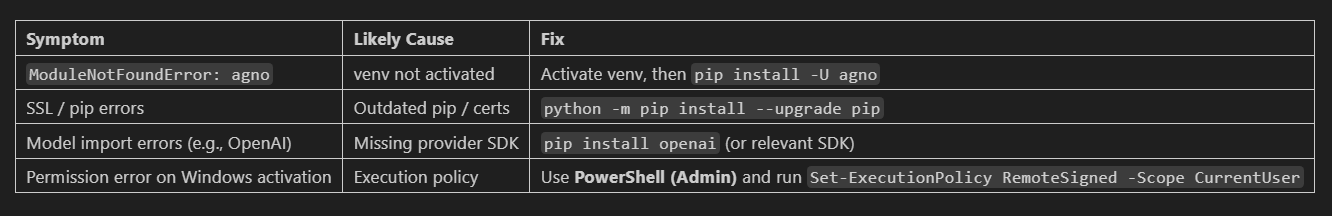

---


## Deactivate / Remove the Environment

- Deactivate:  
```bash
deactivate
```
- Remove (delete the folder):  
  - macOS/Linux: `rm -rf ~/.venvs/agno`  
  - Windows: delete the `agnoenv` directory


---